# Lecture 10 – Classifiers 2: Comparing More Classification Models

In Lecture 9 we cleaned the cuisine data and trained a logistic regression (test accuracy ≈ 0.81).
Next we ask: **can other classifiers do better, and how do we compare them fairly?**

You will:
1. Train several classifiers on exactly the same data split
2. Compare them on accuracy, macro F1 and training time
3. Use **cross-validation** to get more reliable comparisons
4. **Tune** a model's hyperparameters with a grid search
5. Check whether **class weights** help each model with the imbalanced cuisines
6. Look inside the models: which ingredients matter most?

## 0. Setup and data

In [14]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier

RANDOM_STATE = 42   

We load `cleaned_cuisines.csv`. If we don't have it, we can rebuild it as seen below.

In [15]:
try:
    cuisines = pd.read_csv('cleaned_cuisines.csv')
except FileNotFoundError:
    print('cleaned_cuisines.csv not found - rebuilding it from cuisines.csv')
    cuisines = pd.read_csv('cuisines.csv').drop(columns=['Unnamed: 0'])
    features = cuisines.drop(columns='cuisine')
    cuisines = cuisines.drop(columns=features.columns[features.sum() == 0])   # unused ingredients
    cuisines = cuisines.drop_duplicates().reset_index(drop=True)              # duplicate recipes
    cuisines.to_csv('cleaned_cuisines.csv', index=False)

print('Shape:', cuisines.shape)
cuisines['cuisine'].value_counts()

Shape: (2417, 285)


cuisine
korean      784
indian      593
chinese     439
japanese    314
thai        287
Name: count, dtype: int64

We use **exactly the same split as in the first part** (same `test_size`, `stratify` and `random_state`), so the results are comparable.

In [16]:
X = cuisines.drop(columns='cuisine')
y = cuisines['cuisine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
print('Training set:', X_train.shape, ' Test set:', X_test.shape)

Training set: (1691, 284)  Test set: (726, 284)


## 1. Which classifiers should we try?

Walking through the scikit-learn [algorithm cheat-sheet](https://scikit-learn.org/stable/machine_learning_map.html):

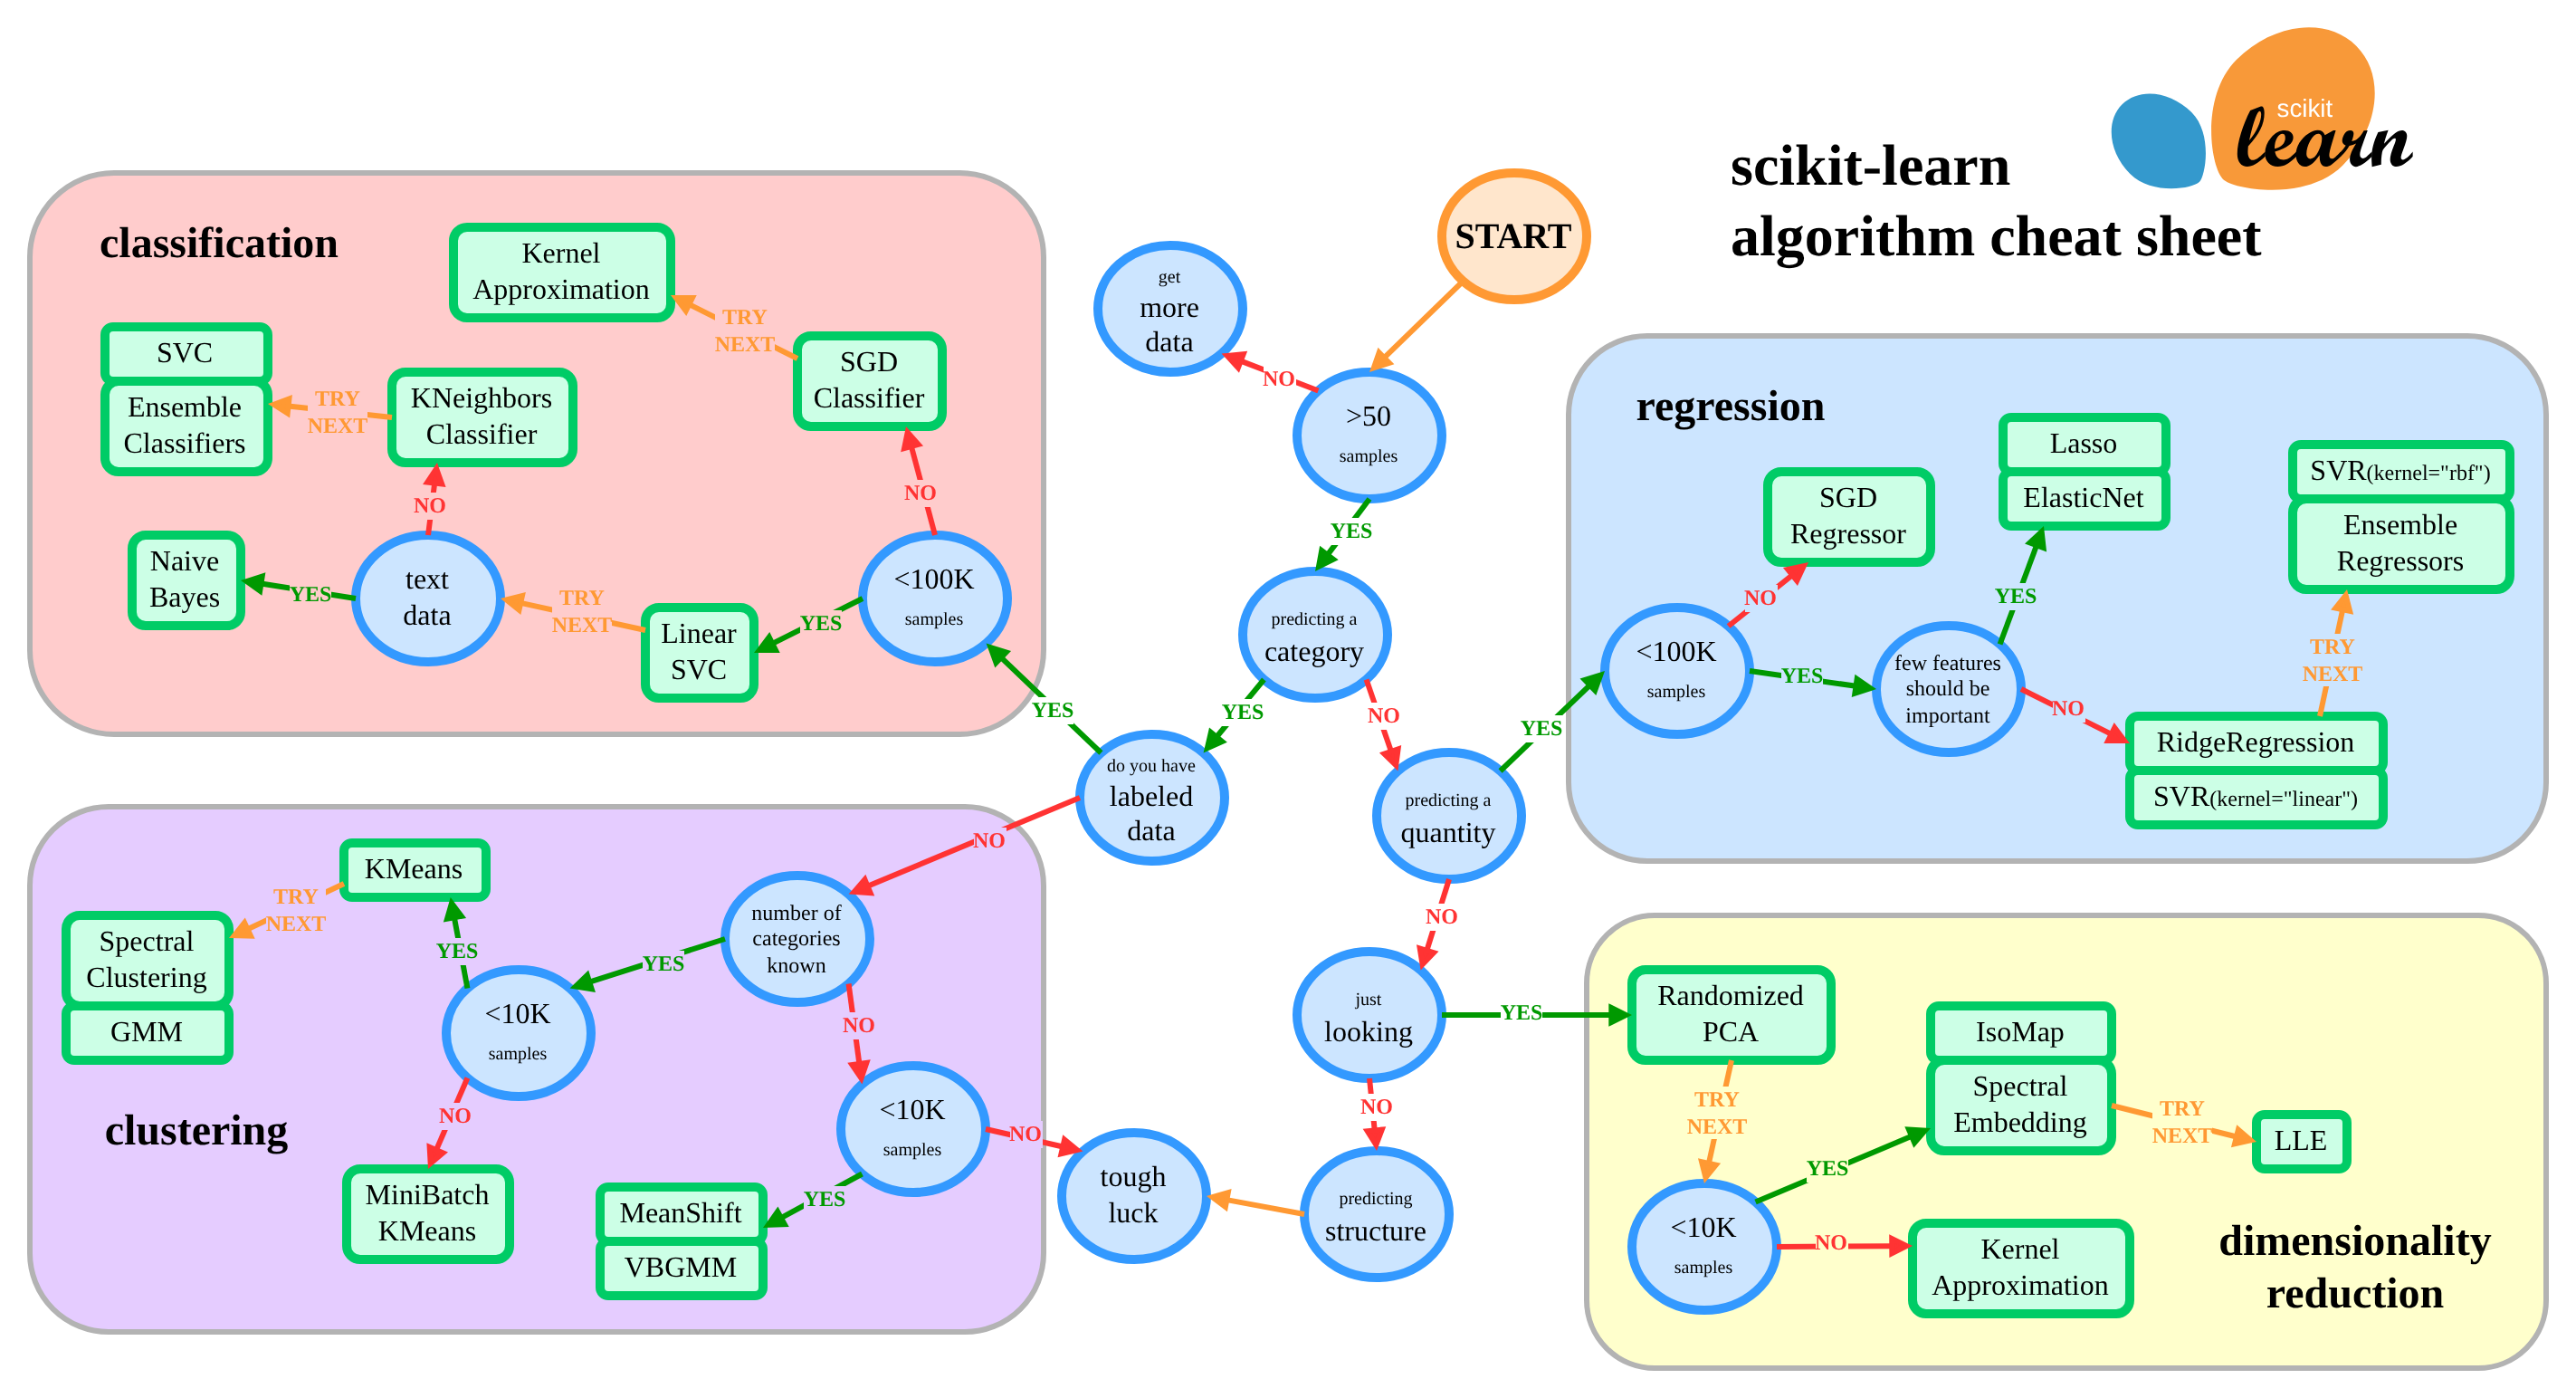

> more than 50 samples → predicting a category → labelled data → fewer than 100K samples → **Linear SVC**
> → not working, and not text data → **KNeighbors Classifier** → not working → **SVC** / **Ensemble classifiers**

We follow that path and keep logistic regression from the first lecture as a reference:

| Model | Idea in one sentence | Decision boundary | Key hyperparameter |
|---|---|---|---|
| Logistic regression | weighted sum of ingredients → probability per cuisine | linear | `C` (regularisation) |
| Linear SVC | linear boundary that leaves the widest possible margin between classes | linear | `C` |
| k-nearest neighbours | look at the *k* most similar recipes and take a vote | very flexible, jagged | `n_neighbors`, `metric` |
| SVC (RBF kernel) | SVM that can bend its boundary using a kernel | smooth, non-linear | `C`, `gamma` |
| Random forest | many decision trees on random subsets, majority vote | axis-aligned boxes | `n_estimators`, `max_depth` |
| AdaBoost | many tiny trees, each one focusing on the previous trees' mistakes | axis-aligned | `n_estimators`, `learning_rate` |
| Gradient boosting | trees added one by one, each correcting the remaining error | axis-aligned | `learning_rate`, `max_iter` |

Our features are 0/1 ingredient flags, so they are already on the same scale and we don't need to standardise them for k-NN and SVC.

In [17]:
models = {
    'Dummy (most frequent)': DummyClassifier(strategy='most_frequent'),
    'Logistic regression':   LogisticRegression(max_iter=1000),
    'Linear SVC':            LinearSVC(C=1.0, random_state=RANDOM_STATE),
    'k-NN (k=10)':           KNeighborsClassifier(n_neighbors=10),
    'SVC (RBF kernel)':      SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE),
    'Random forest':         RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'AdaBoost':              AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient boosting':     HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

### The classifiers

**Dummy (most frequent)**
Not a real model: it ignores the ingredients and always predicts the most common cuisine (Korean).
It learns nothing, which makes it a useful **baseline**: any real model must beat it to be worth anything.

**Logistic regression**
Gives every ingredient a weight for each cuisine, adds up the weights of the ingredients in a recipe, and turns the totals into probabilities (softmax).
The cuisine with the highest probability wins. The weights are easy to read: a large positive weight means "this ingredient points to this cuisine".

**Linear SVC (support vector classifier)**
Also draws straight boundaries between the cuisines, but chooses them so that the gap (margin) to the nearest recipes of each cuisine is as wide as possible.
Only the recipes close to the boundary, the *support vectors*, decide where it goes. It gives scores, not probabilities.

**k-nearest neighbours (k-NN)**
Doesn't really train: it just stores all training recipes.
To classify a new recipe, it finds the *k* most similar recipes and picks the cuisine that appears most often among them. Everything depends on how "similar" is measured (e.g. Euclidean vs. cosine distance).

**SVC with RBF kernel**
Like Linear SVC, but it can draw curved boundaries instead of straight ones.
It does this by comparing each recipe with the support vectors through a similarity function (the kernel), which lets it capture more complex patterns.

**Random forest**
Builds hundreds of decision trees, each asking yes/no questions like "does the recipe contain soy sauce?".
Every tree sees a random sample of recipes and ingredients, so the trees make different mistakes. The forest predicts the cuisine that most trees agree on, which cancels out many of those mistakes.

**AdaBoost**
Builds many very small trees one after another.
After each tree, recipes it got wrong get a higher weight, so the next tree focuses on the hard cases. In the end, the predictions of all trees are combined, with the better trees counting more.

**Gradient boosting**
Also builds trees one after another, but each new tree tries to correct the remaining errors of all trees before it.
Step by step, these small corrections add up to a strong model. It is often very accurate, but slower to train.

## 2. Train and test every model once

In [18]:
rows, predictions = [], {}
for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    rows.append({'model': name,
                 'test accuracy': accuracy_score(y_test, y_pred),
                 'test macro F1': f1_score(y_test, y_pred, average='macro'),
                 'fit time (s)': fit_time})

results = pd.DataFrame(rows).set_index('model').sort_values('test macro F1', ascending=False)
results.round(3)

,test accuracy,test macro F1,fit time (s)
model,,,
Gradient boosting,0.809,0.780,3.263
SVC (RBF kernel),0.806,0.773,0.111
Logistic regression,0.807,0.773,0.057
Linear SVC,0.802,0.768,0.018
Random forest,0.796,0.763,0.217
AdaBoost,0.713,0.685,0.463
k-NN (k=10),0.719,0.658,0.002
Dummy (most frequent),0.325,0.098,0.004


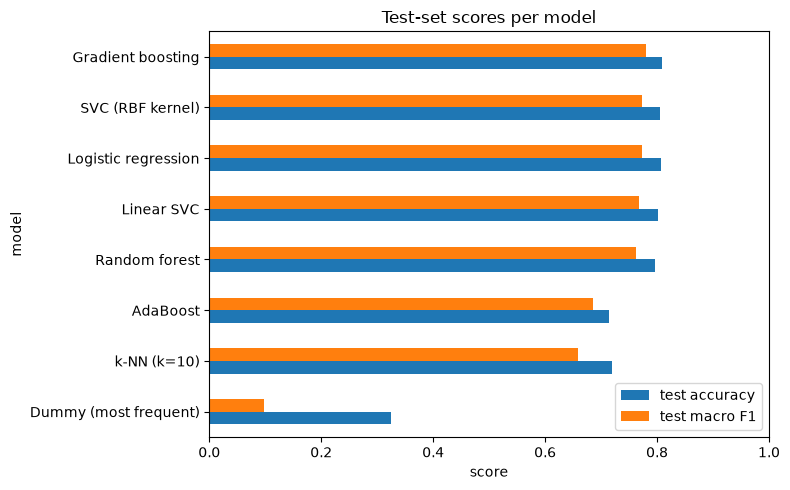

In [19]:
ax = results[['test accuracy', 'test macro F1']].sort_values('test macro F1').plot.barh(figsize=(8, 5))
ax.set_xlim(0, 1)
ax.set_title('Test-set scores per model')
ax.set_xlabel('score')
plt.tight_layout()
plt.show()

<span style="color:red;"><b>Question:</b> Why do we report macro F1 next to accuracy?</span>

<span style="color:green;"><b>Answer:</b></span><br>
Our cuisines are imbalanced. Accuracy is dominated by the big classes (Korean, Indian), while macro F1 gives every cuisine the same weight.
A model that ignores Thai recipes can still have good accuracy, but its macro F1 will drop.

<span style="color:red;"><b>Question:</b> Why does the Dummy (most frequent) model have a much lower test macro F1 than test accuracy?</span>

<span style="color:green;"><b>Answer:</b></span><br>
The dummy model predicts "Korean" for every recipe, without looking at the ingredients.

Its **accuracy** is 0.325, because about a third of the test recipes really are Korean, so it gets exactly those right.
Accuracy counts every recipe equally, so being right about the biggest cuisine is enough to get a decent-looking number.

**Macro F1** works differently: it calculates an F1 score for each cuisine separately and then averages them, so every cuisine counts equally.
- For **Korean**, recall is perfect (1.0), since every Korean recipe is found, but precision is only 0.325, because two thirds of the recipes it calls Korean are wrong. That gives an F1 of about 0.49.
- For the **other four cuisines**, the model never predicts them, so it finds none of their recipes and their F1 is 0.

The average is (0.49 + 0 + 0 + 0 + 0) / 5 ≈ **0.098**.

So accuracy makes the dummy look somewhat useful, while macro F1 shows that it's useless for four out of five cuisines. This is exactly why we report macro F1 next to accuracy when the classes are imbalanced.

## 3. A fairer comparison: cross-validation

The numbers above come from **one** split of 726 test recipes. A different split would give slightly different numbers, and small differences between models may just be luck.

**k-fold cross-validation** splits the *training* data into k parts, trains on k−1 parts and validates on the remaining one, k times. We get k scores per model: the mean tells us how good the model is, the standard deviation how stable.

Here, we use **5-fold cross-validation**. There is no magic number: 5 and 10 are the most common choices. A larger k gives each model slightly more training data, but the validation folds get smaller (noisier scores for small cuisines) and the run time grows, since every extra fold means training each model once more.

The test set stays untouched — it's for the final check only.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    cv_rows.append({'model': name,
                    'CV accuracy (mean)': scores['test_accuracy'].mean(),
                    'CV macro F1 (mean)': scores['test_f1_macro'].mean(),
                    'CV macro F1 (std)':  scores['test_f1_macro'].std()})

cv_results = pd.DataFrame(cv_rows).set_index('model').sort_values('CV macro F1 (mean)', ascending=False)
cv_results.round(3)

,CV accuracy (mean),CV macro F1 (mean),CV macro F1 (std)
model,,,
SVC (RBF kernel),0.803,0.771,0.011
Logistic regression,0.800,0.770,0.013
Gradient boosting,0.785,0.756,0.021
Linear SVC,0.784,0.750,0.016
Random forest,0.785,0.749,0.014
AdaBoost,0.721,0.693,0.031
k-NN (k=10),0.725,0.667,0.008
Dummy (most frequent),0.324,0.098,0.000


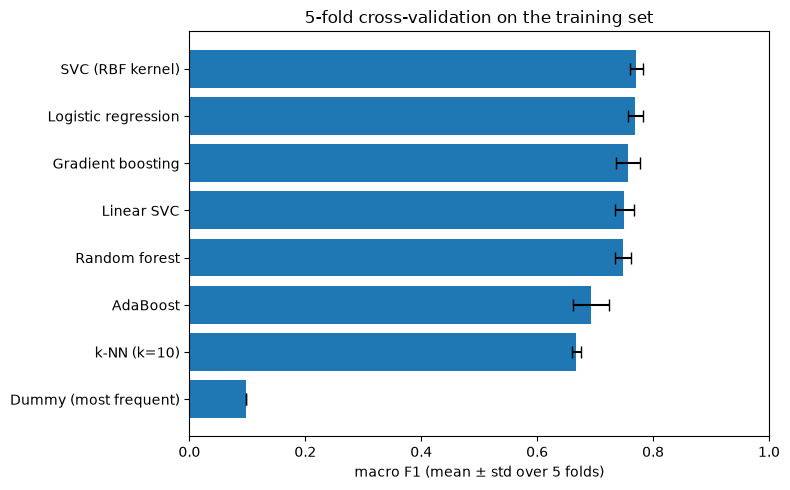

In [21]:
plot_df = cv_results.sort_values('CV macro F1 (mean)')
plt.figure(figsize=(8, 5))
plt.barh(plot_df.index, plot_df['CV macro F1 (mean)'], xerr=plot_df['CV macro F1 (std)'], capsize=4)
plt.xlim(0, 1)
plt.xlabel('macro F1 (mean ± std over 5 folds)')
plt.title('5-fold cross-validation on the training set')
plt.tight_layout()
plt.show()

### What cross-validation tells us

In the plot, each bar shows a model's **mean** macro F1 over the 5 folds, and the whiskers show **± one standard deviation**: roughly the range its score moved within from fold to fold.<br>
If two models' ranges overlap a lot, the difference between them could just be luck. If they don't overlap, the difference is likely real.<br>

On the single test split, **gradient boosting** looked best. In cross-validation it drops to third place, behind **SVC** and **logistic regression**. Its test-set lead was partly luck of the split.<br>
The top five models are all within about 0.02 macro F1 of each other, roughly one or two standard deviations. On this dataset they are practically **tied**.<br>
Take the two top models: **SVC** scores 0.771 ± 0.011, so usually between about 0.760 and 0.782, and **logistic regression** 0.770 ± 0.013, so between about 0.757 and 0.783.<br>
Those ranges are almost identical. The gap between their averages (0.001) is tiny compared to how much each score moves from fold to fold (about 0.01), so with different folds the order could easily flip.<br>
When models are tied, prefer the **simpler and faster** one: logistic regression trains in a fraction of a second and is easy to explain (section 7a). Gradient boosting takes about 60× longer here.<br>
**AdaBoost** and **k-NN** are clearly behind with their current settings.<br>
For example, **k-NN** scores 0.659 ± 0.016, so between about 0.643 and 0.675. Its whole range sits far below the lowest point of the top models (around 0.757): no matter which fold you look at, k-NN does worse. That gap is real, not luck.<br>
Model to choose solely based on cross-validation: logistic regression wins, the score is almost identical to SVC but has a lower compute cost.

### Narrowing down the models

From here on, we continue with **four models**: logistic regression, SVC (RBF kernel), gradient boosting and k-NN. Based on the cross-validation results, we drop the other four:

- **Dummy (most frequent):** it was only a baseline. It has done its job by showing what "learning nothing" scores (macro F1 0.098), and every real model beats it by far.
- **AdaBoost:** clearly behind the top group (0.693 ± 0.031) and the least stable model, with the largest standard deviation of all.
- **Linear SVC:** practically tied with the top models (0.750), but it's another linear model, just like logistic regression, which scores a little higher and also gives probabilities and easy-to-read weights. Keeping both would teach us little new.
- **Random forest:** also close to the top (0.751), but it's a tree ensemble, just like gradient boosting, which scored a little higher (0.756). Gradient boosting represents the tree-based models from now on.

This leaves one model of each type: a **linear model** (logistic regression), a **kernel model** (SVC), a **tree ensemble** (gradient boosting) and an **instance-based model** (k-NN).
We keep **k-NN** even though it scored low, because we want to understand *why* it does badly and whether better settings can fix it (sections 4 and 5).

## 4. Where do the models make mistakes?

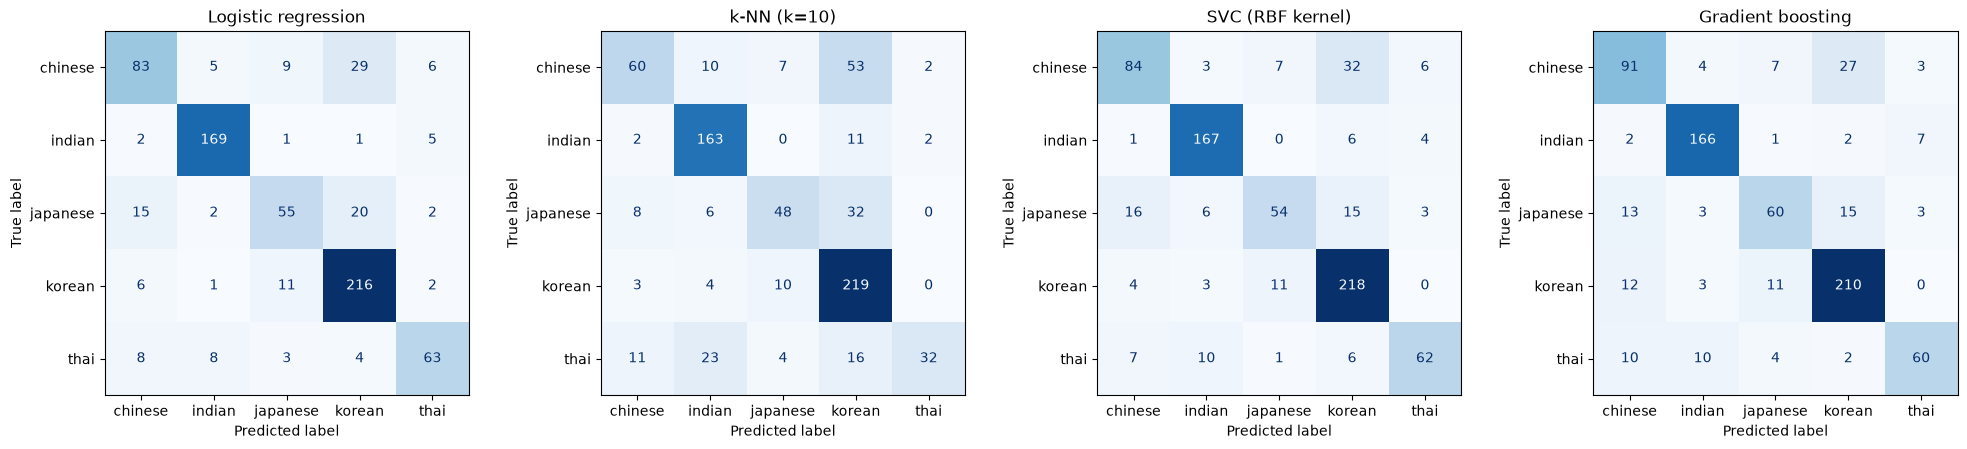

In [22]:
show = ['Logistic regression', 'k-NN (k=10)', 'SVC (RBF kernel)', 'Gradient boosting']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, name in zip(axes, show):
    ConfusionMatrixDisplay.from_predictions(y_test, predictions[name], ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

Rows = true cuisine, columns = predicted cuisine.

In [23]:
for name in show: 
    print(f'{name}')
    print(classification_report(y_test, predictions[name], digits=3))

Logistic regression
              precision    recall  f1-score   support

     chinese      0.728     0.629     0.675       132
      indian      0.914     0.949     0.931       178
    japanese      0.696     0.585     0.636        94
      korean      0.800     0.915     0.854       236
        thai      0.808     0.733     0.768        86

    accuracy                          0.807       726
   macro avg      0.789     0.762     0.773       726
weighted avg      0.802     0.807     0.802       726

k-NN (k=10)
              precision    recall  f1-score   support

     chinese      0.714     0.455     0.556       132
      indian      0.791     0.916     0.849       178
    japanese      0.696     0.511     0.589        94
      korean      0.662     0.928     0.772       236
        thai      0.889     0.372     0.525        86

    accuracy                          0.719       726
   macro avg      0.750     0.636     0.658       726
weighted avg      0.734     0.719     0.699  

<span style="color:red;"><b>Question:</b> What goes wrong with k-NN?</span>

<span style="color:green;"><b>Answer:</b></span><br>

**How we noticed something was wrong**

k-NN scored lowest of all real models, both on the test set and in cross-validation (macro F1 about 0.66, against about 0.77 for the best models).
The confusion matrix and classification report show *where* it fails:
- **Korean:** recall 0.94, but precision only 0.68, so almost a third of its "Korean" predictions are wrong. The Korean column is full of numbers outside the diagonal, including 51 Chinese recipes. k-NN predicts "Korean" far too often.
- **Thai:** recall only 0.38, with many Thai recipes labelled as Indian.

**Why it happens: Euclidean distance**

k-NN finds a recipe's *k* most similar recipes and picks the cuisine that appears most often among them, so everything depends on how we measure "similar".
By default it uses **Euclidean distance**, the straight-line distance between two points. On 0/1 data, this boils down to counting the ingredients that appear in one recipe but not the other.

As a result, short recipes are close to each other even when they share nothing. Take recipe A with 4 ingredients:
- Recipe B has 4 **completely different** ingredients: they differ in 8.
- Recipe C shares **3** of A's ingredients but has 15 in total: they differ in 13.

So B counts as closer, although C is clearly the more similar recipe. Neighbours are chosen by **how many** ingredients a recipe has, not **which** ones, and in such a mixed bag the biggest cuisine (Korean) wins most often.

**What we do about it: cosine distance**

**Cosine distance** compares the shared ingredients *relative to* the size of both recipes, so recipe length no longer dominates. In the example, B (nothing shared) is now far away and C (3 shared) is the closer neighbour.

In the next section, a grid search tries both distance measures with different values of *k*.

## 5. Tuning hyperparameters with a grid search

k-NN did poorly with its default settings. Maybe it just needs better ones. `GridSearchCV` tries every combination of settings with cross-validation **on the training set** and keeps the best.

For 0/1 recipe data, **cosine** distance is often a better similarity measure than straight-line (Euclidean) distance: two recipes are similar if they *share* ingredients, regardless of how many ingredients they have.

In [24]:
param_grid = {
    'n_neighbors': [5, 10, 20, 40],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'cosine'],
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best settings:', grid.best_params_)
print('Best CV macro F1:', round(grid.best_score_, 3))

tuned_pred = grid.predict(X_test)
print('Test macro F1 of tuned k-NN:', round(f1_score(y_test, tuned_pred, average='macro'), 3),
      ' (default k-NN:', round(f1_score(y_test, predictions['k-NN (k=10)'], average='macro'), 3), ')')

Best settings: {'metric': 'cosine', 'n_neighbors': 10, 'weights': 'uniform'}
Best CV macro F1: 0.751
Test macro F1 of tuned k-NN: 0.735  (default k-NN: 0.658 )


In [25]:
grid_df = pd.DataFrame(grid.cv_results_)
pivot = grid_df.pivot_table(index='param_n_neighbors', columns=['param_metric', 'param_weights'],
                            values='mean_test_score')
pivot.round(3)

param_metric        cosine         euclidean        
param_weights     distance uniform  distance uniform
param_n_neighbors                                   
5                    0.740   0.738     0.662   0.653
10                   0.749   0.751     0.666   0.667
20                   0.734   0.735     0.631   0.627
40                   0.692   0.676     0.567   0.558

### What the grid search tells us
- The **distance metric** matters much more than the number of neighbours: switching from Euclidean to **cosine** lifts macro F1 from about 0.66 to about 0.75.
- `weights='distance'` vs `'uniform'` makes almost no difference, and very large *k* (40) hurts.
- Tuned k-NN closes most of the gap, but it still doesn't beat logistic regression. Tuning helps, but it can't turn a poorly matched model into the best one.

## 6. Class weights: does balancing help every model?

In the first lecture, we saw that `class_weight='balanced'` makes mistakes on small cuisines cost more, so the model can't simply favour the big ones (Korean, Indian).
Here we check whether that holds for the other classifiers too.

Not every model supports it:

| Model | `class_weight`? | Why |
|---|---|---|
| Logistic regression, Linear SVC, SVC | ✅ | the training loss counts each mistake, so mistakes can be weighted |
| Random forest, Gradient boosting | ✅ | each recipe's weight is used when the trees choose their splits |
| k-NN | ❌ | there is no training loss: k-NN just stores the recipes and votes at prediction time |
| AdaBoost | ❌ (no parameter) | it already reweights recipes itself; you could pass `sample_weight` to `fit` instead |

For each model that supports it, we train two versions, with and without class weights, and compare them with the same cross-validation as in section 3. We also look at **balanced accuracy** (the average recall over the cuisines) and at the test-set recall per cuisine.

In [26]:
from sklearn.base import clone
from sklearn.metrics import recall_score

weightable = ['Logistic regression', 'Linear SVC', 'SVC (RBF kernel)', 'Random forest', 'Gradient boosting']
cuisine_labels = sorted(y.unique())

cw_rows = []
for name in weightable:
    for weighting in [None, 'balanced']:
        model = clone(models[name]).set_params(class_weight=weighting)   # a fresh, untrained copy
        scores = cross_validate(model, X_train, y_train, cv=cv,
                                scoring=['f1_macro', 'balanced_accuracy'], n_jobs=-1)
        model.fit(X_train, y_train)
        test_recall = recall_score(y_test, model.predict(X_test), average=None, labels=cuisine_labels)
        cw_rows.append({'model': name,
                        'class_weight': weighting or 'none',
                        'CV macro F1': scores['test_f1_macro'].mean(),
                        'CV balanced acc.': scores['test_balanced_accuracy'].mean(),
                        **{f'recall {c}': r for c, r in zip(cuisine_labels, test_recall)}})

cw_results = pd.DataFrame(cw_rows).set_index(['model', 'class_weight'])
cw_results.round(3)

CV macro F1  CV balanced acc.  \
model               class_weight                                  
Logistic regression none                0.770             0.762   
                    balanced            0.772             0.777   
Linear SVC          none                0.750             0.744   
                    balanced            0.760             0.760   
SVC (RBF kernel)    none                0.771             0.755   
                    balanced            0.784             0.781   
Random forest       none                0.749             0.730   
                    balanced            0.777             0.771   
Gradient boosting   none                0.756             0.749   
                    balanced            0.746             0.742   

                                  recall chinese  recall indian  \
model               class_weight                                  
Logistic regression none                   0.629          0.949   
                    balanced               0.682          0.944   
Linear SVC          none                   0.614          0.944   
                    balanced               0.636          0.944   
SVC (RBF kernel)    none                   0.636          0.938   
                    balanced               0.667          0.933   
Random forest       none                   0.636          0.949   
                    balanced               0.697          0.933   
Gradient boosting   none                   0.689          0.933   
                    balanced               0.689          0.933   

                                  recall japanese  recall korean  recall thai  
model               class_weight                                               
Logistic regression none                    0.585          0.915        0.733  
                    balanced                0.649          0.822        0.767  
Linear SVC          none                    0.574          0.903        0.767  
                    balanced                0.606          0.847        0.767  
SVC (RBF kernel)    none                    0.574          0.924        0.721  
                    balanced                0.670          0.856        0.733  
Random forest       none                    0.532          0.919        0.674  
                    balanced                0.691          0.886        0.733  
Gradient boosting   none                    0.638          0.890        0.698  
                    balanced                0.649          0.873        0.686

The table is easier to read if we look only at the **change** caused by class weights (balanced minus none) for each model:

In [27]:
cw_change = (cw_results.xs('balanced', level='class_weight')
             - cw_results.xs('none', level='class_weight'))
cw_change.round(3)

,CV macro F1,CV balanced acc.,recall chinese,recall indian,recall japanese,recall korean,recall thai
model,,,,,,,
Logistic regression,0.003,0.015,0.053,-0.006,0.064,-0.093,0.035
Linear SVC,0.009,0.016,0.023,0.000,0.032,-0.055,0.000
SVC (RBF kernel),0.013,0.026,0.030,-0.006,0.096,-0.068,0.012
Random forest,0.028,0.041,0.061,-0.017,0.160,-0.034,0.058
Gradient boosting,-0.011,-0.006,0.000,0.000,0.011,-0.017,-0.012


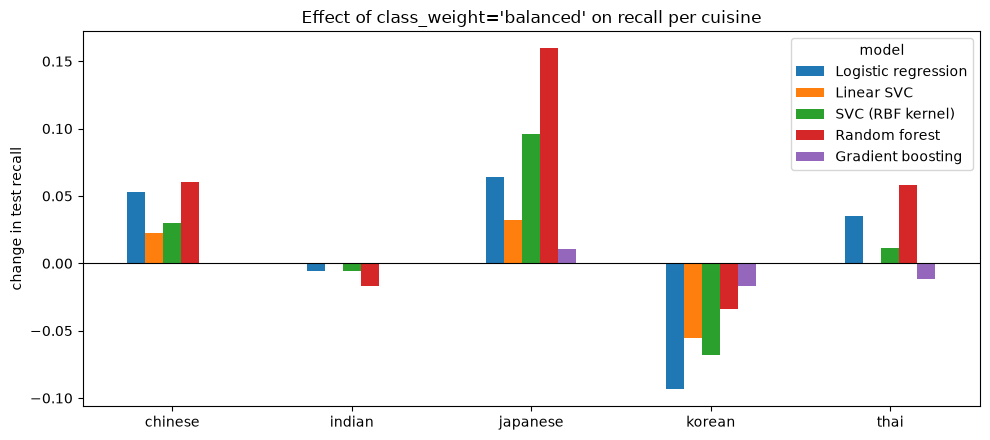

In [28]:
recall_cols = [f'recall {c}' for c in cuisine_labels]
ax = cw_change[recall_cols].T.plot.bar(figsize=(10, 4.5))
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticklabels(cuisine_labels, rotation=0)
ax.set_ylabel('change in test recall')
ax.set_title('Effect of class_weight=\'balanced\' on recall per cuisine')
plt.tight_layout()
plt.show()

### What class weights change
- The main effect is a shift in **recall**. Japanese, the cuisine all models found hardest, gains the most (up to +0.10 for SVC), mostly at the cost of Korean.
- For the linear models and SVC, the overall scores also improve a little: balanced accuracy rises by 0.015–0.026 and macro F1 by up to 0.013.
- Weighted **SVC** (CV macro F1 0.784) is now the best model in this lecture. The gain over unweighted SVC is about one standard deviation, though, so treat it as a small improvement, not a clear win.
- Tree ensembles react less: the random forest changes little (its Korean recall even rises slightly), and gradient boosting gets slightly *worse* (−0.011 macro F1).
- Class weights cost one argument to try, but whether they help depends on the model. Check with cross-validation, as we did here.

### Why recall changes so much

Class weights mostly affect the **ambiguous recipes**: the ones that could belong to more than one cuisine.

- **The boundary moves:** a mistake on a Japanese recipe (weight about 1.54) now costs about 2.5 times as much as one on a Korean recipe (about 0.62). To reduce its errors, the model shifts its boundary, so recipes that could go either way are labelled Japanese more often.
- **Japanese has many ambiguous recipes:** because Japanese and Korean share many ingredients, lots of Japanese recipes sit right next to that boundary. A small shift moves a whole group of them to the right side, so Japanese recall jumps. Indian recipes are far from any boundary, so Indian barely changes.
- **Korean pays for it:** the same shift catches some Korean recipes that look a bit Japanese or Chinese, so Korean recall drops.
- **The numbers look bigger than they are:** with about 94 Japanese test recipes, +0.10 recall means only about 9 more recipes found. Since Korean loses some on the other side, accuracy and macro F1 barely move: the model mostly *trades* mistakes between cuisines.
- **SVC reacts most:** its boundary is shaped by the recipes closest to it, which are exactly these ambiguous ones. Tree models react less, because many of their groups of recipes were already clearly one cuisine.

<span style="color:red;"><b>Question:</b> For logistic regression and the two SVMs, Korean recall goes down when we add class weights. Is the model getting worse?</span>

<span style="color:green;"><b>Answer:</b></span><br>
Not necessarily. Without weights, the model predicts Korean very often because it's the biggest class, which gives high Korean recall but sends many Chinese and Japanese recipes to Korean by mistake.
Class weights make it predict Korean less readily: a few more Korean recipes are missed, but more of the smaller cuisines are found. Whether that trade is worth it depends on which mistakes matter more for your goal.

## 7. What has each model learned?

### 7a. Logistic regression: the ingredients that point to each cuisine
A linear model has one weight (coefficient) per ingredient **per cuisine**. Large positive weights push a recipe towards that cuisine.

We can only read the learned parameters directly for logistic regression. The other models don't work this way:
- **SVC (RBF kernel)** has no weight per ingredient. Its decisions come from comparing each recipe with hundreds of support vectors through the kernel, so there's nothing simple to print.
- **k-NN** doesn't learn any parameters at all. It just stores the training recipes, so there's nothing inside to inspect.
- **Gradient boosting** consists of hundreds of small trees, each correcting the previous ones. You could look at a single tree, but it would only show a tiny part of the picture.

For models like these, we need a different method, which is what section 7c is about.

In [29]:
logreg = models['Logistic regression']
coefs = pd.DataFrame(logreg.coef_, index=logreg.classes_, columns=X.columns)

top_per_cuisine = pd.DataFrame({cuisine: coefs.loc[cuisine].sort_values(ascending=False).head(8).index
                                for cuisine in logreg.classes_})
top_per_cuisine.index = [f'#{i}' for i in range(1, 9)]
top_per_cuisine

,chinese,indian,japanese,korean,thai
#1,starch,cardamom,seaweed,black_sesame_seed,lemongrass
#2,star_anise,yogurt,sake,roasted_sesame_seed,coconut
#3,lard,cumin,barley,nut,peanut_butter
#4,walnut,tamarind,wasabi,pumpkin,fish
#5,date,lemon_juice,green_tea,pear,basil
#6,pork,turmeric,buckwheat,soybean,lime_juice
#7,peanut_oil,lime,wine,red_bean,cilantro
#8,broccoli,olive_oil,soy_sauce,raisin,peanut


These lists are easy to check with common sense — a good sign the model has learned something real.
(The same works for `LinearSVC`: it trains one-vs-rest, so its `coef_` also has one row per cuisine. Be careful with `SVC(kernel='linear')`, which uses one-vs-*one*: its `coef_` has one row per *pair* of cuisines.)

### 7b. Random forest: impurity-based feature importance
A decision tree splits recipes into groups with yes/no questions like "does it contain soy sauce?". **Impurity** measures how mixed a group is: a group with only Korean recipes is pure (impurity 0), while a group with half Korean and half Indian recipes is impure. At each split, the tree picks the ingredient that makes the new groups as pure as possible.

Tree ensembles have a built-in `feature_importances_`: how much each ingredient reduced impurity across all splits in all trees. It gives one global number per ingredient, not one per cuisine: it tells us how **useful** an ingredient is for separating the cuisines, but not **which** cuisine it points to.

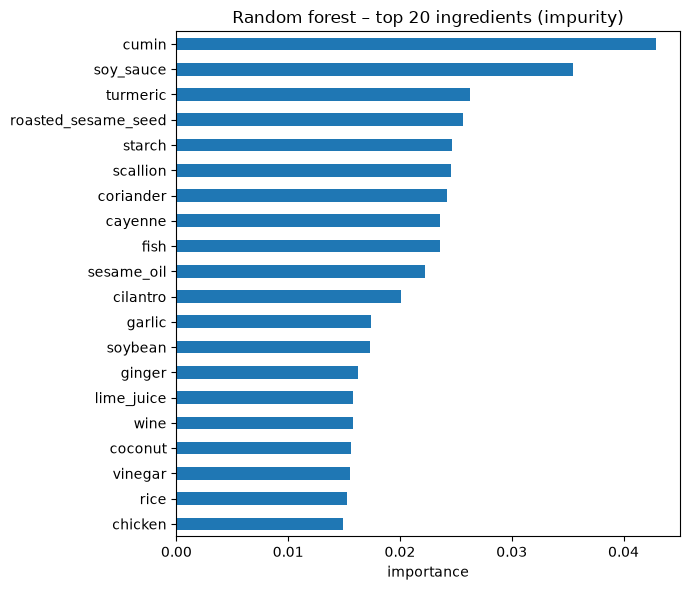

In [30]:
rf = models['Random forest']
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

rf_importance.head(20).sort_values().plot.barh(figsize=(7, 6), title='Random forest – top 20 ingredients (impurity)')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

### 7c. Permutation importance: works for any model
Impurity importance is fast but can be biased, and models like SVC or k-NN don't have it at all.
**Permutation importance** is model-agnostic: shuffle one ingredient column in the test set and measure how much the score drops. A big drop means the model relies on that ingredient.

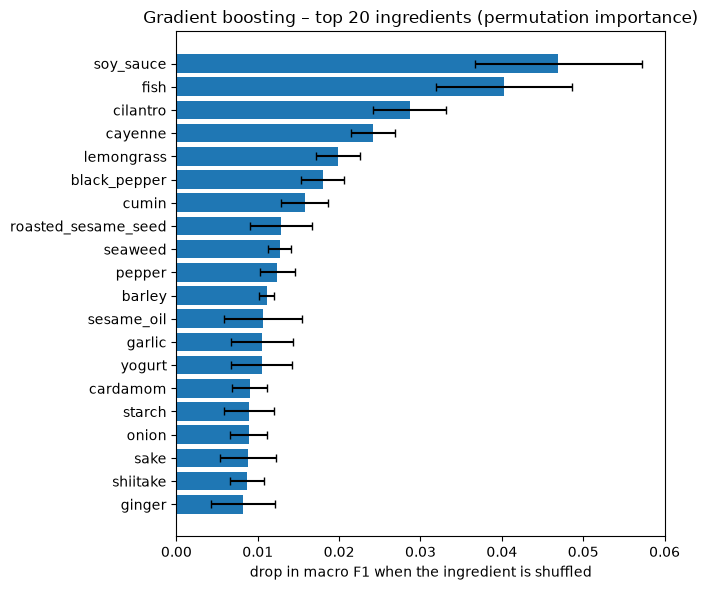

In [ ]:
best_name = 'Gradient boosting'   # a non-linear model with no coefficients to inspect
best_model = models[best_name]

# each of the ~280 columns is shuffled 5 times and re-scored
perm = permutation_importance(best_model, X_test, y_test, scoring='f1_macro',
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.DataFrame({'mean': perm.importances_mean, 'std': perm.importances_std},
                               index=X.columns).sort_values('mean', ascending=False)

top = perm_importance.head(20).iloc[::-1]
plt.figure(figsize=(7, 6))
plt.barh(top.index, top['mean'], xerr=top['std'], capsize=3)
plt.xlabel('drop in macro F1 when the ingredient is shuffled')
plt.title(f'{best_name} – top 20 ingredients (permutation importance)')
plt.tight_layout()
plt.show()

### Reading the importance plots
- Both methods agree on several key ingredients: **soy sauce, cumin, fish, cayenne, cilantro, roasted sesame seed**.
- Notice that **soy sauce, cayenne, garlic and ginger** are among the most important ingredients. These are exactly the "common" ingredients that one might be tempted to delete (Lecture 1, section 4c). Common overall ≠ useless.
- The two rankings are not identical: they measure different things (how often a tree *splits* on an ingredient vs how much the *score drops* without it), and they come from different models.
- Importance tells you what the model **uses**, not what *causes* a dish to belong to a cuisine.

## 8. Summary

- Compare models on the **same split**, against a **baseline**, with more than one metric.
- A single test split is noisy; **cross-validation** shows whether differences are real.
- **Class weights** are a one-line way to handle imbalance for most models. They mainly shift recall from the big cuisines to the small ones; check per-class recall, not just the overall score.
- Hyperparameters matter: a grid search with sensible options (here: cosine distance for k-NN) can change the ranking.
- More complex isn't automatically better: on this small, sparse dataset, simple linear models are hard to beat.
- Model inspection: coefficients (linear models), impurity importance (trees), permutation importance (any model). Always sanity-check what the model relies on.

## Exercises
1. Tune `C` for `SVC` (try 0.3, 1, 3, 10) with `GridSearchCV`. Does it overtake logistic regression?
2. Class weights don't have to be `'balanced'`. Give the logistic regression your own weights, e.g. `class_weight={'japanese': 2, 'chinese': 1.5}` (cuisines you leave out keep weight 1). Can you beat `'balanced'` on macro F1?
3. Build a `VotingClassifier` from logistic regression, SVC and gradient boosting (`voting='hard'`). Is the team better than its best member?
4. The random forest and permutation importances disagree on some ingredients. Pick one ingredient that differs and explain why the two methods might rank it differently.